# Bài 2: Phân loại văn bản Naive Bayes với Laplace Smoothing (MAP)

## 1. Mô tả bài toán
- Xây dựng bộ phân loại văn bản đơn giản (phân loại Email Spam / Ham) sử dụng mô hình **Multinomial Naive Bayes từ đầu (from scratch)** chỉ sử dụng thư viện **NumPy**.
- Hai lớp văn bản cần phân loại: $C = \{\text{Spam}, \text{Ham}\}$.

## 2. Cơ sở lý thuyết & Công thức toán học

### a. Xác suất tiên nghiệm của lớp $P(C_k)$ (MLE):
$$P(C_k) = \frac{N_{C_k}}{N}$$
Trong đó: $N_{C_k}$ là số lượng văn bản thuộc lớp $C_k$, và $N$ là tổng số văn bản huấn luyện.

### b. Xác suất từ vựng có điều kiện $P(w_i \mid C_k)$:
- **Theo MLE (Maximum Likelihood Estimation - không làm trơn):**
  $$P_{MLE}(w_i \mid C_k) = \frac{count(w_i, C_k)}{\sum_{w \in V} count(w, C_k)}$$
  - **Hiện tượng tần suất bằng 0 (Zero-Frequency Problem):** Nếu từ $w_i$ chưa từng xuất hiện trong lớp $C_k$ ở tập huấn luyện, thì $P_{MLE}(w_i \mid C_k) = 0$. Khi tính xác suất của văn bản $P(D \mid C_k) = \prod_i P(w_i \mid C_k)$, một từ có xác suất bằng $0$ sẽ làm triệt tiêu toàn bộ xác suất của lớp đó về $0$, bất kể các từ khác trong văn bản ủng hộ lớp đó như thế nào.

- **Theo MAP (Maximum A Posteriori) với Laplace Smoothing:**
  - Phân phối đa thức (Multinomial distribution) có phân phối tiên nghiệm liên hợp (conjugate prior) là phân phối Dirichlet đối xứng: $\theta_{C_k} \sim \text{Dirichlet}(\alpha, \alpha, \dots, \alpha)$.
  - Điểm cực đại hậu nghiệm (Mode) cho ta công thức **Laplace Smoothing** (khi chọn $\alpha = 1$):
  $$P_{MAP}(w_i \mid C_k) = \frac{count(w_i, C_k) + \alpha}{\sum_{w \in V} count(w, C_k) + \alpha \cdot |V|}$$
  Trong đó: $|V|$ là kích thước toàn bộ không gian từ vựng (Vocabulary size), $\alpha \ge 0$ là siêu tham số làm trơn (thường $\alpha = 1$).

### c. Hàm dự đoán trên Log-Space (Chống tràn số dưới - Numerical Underflow):
Nhân nhiều xác suất nhỏ ($< 1$) sẽ dẫn đến tràn số dưới trong máy tính. Do đó, ta chuyển sang tính toán trên miền log:
$$\hat{y} = \arg\max_{C_k} \left[ \ln P(C_k) + \sum_{w_i \in D} \ln P(w_i \mid C_k) \right]$$

In [1]:
# ==============================================================================
# 0. Import thư viện & Chuẩn bị dữ liệu mẫu (Toy Dataset)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import re

# Hàm tiền xử lý văn bản: chuyển chữ thường, tách từ
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

# Tập dữ liệu huấn luyện (Training Set)
train_X = [
    "buy cheap watches free shipping today",              # Spam
    "exclusive deal win cash prize claim now",             # Spam
    "congratulations winner claim free gift reward now",   # Spam
    "click here for free credit card loan deal",          # Spam
    "project meeting scheduled tomorrow morning",         # Ham
    "please send the quarterly report for review",       # Ham
    "team lunch together at office cafeteria",           # Ham
    "discussion on machine learning assignment project"   # Ham
]
train_y = np.array(["spam", "spam", "spam", "spam", "ham", "ham", "ham", "ham"])

# Tập dữ liệu kiểm tra (Test Set) chứa cả từ đã biết và từ mới (OOV / Zero-frequency)
test_X = [
    "claim your free cash prize today",           # Spam chuẩn (chứa free, cash, prize)
    "exclusive discount deal buy now",           # Spam có từ mới 'discount'
    "meeting tomorrow for project review",        # Ham chuẩn (chứa meeting, project, review)
    "can you send report before lunch"           # Ham có từ mới 'before', 'can'
]
test_y = np.array(["spam", "spam", "ham", "ham"])

print(f"Số lượng văn bản Train: {len(train_X)}")
print(f"Số lượng văn bản Test: {len(test_X)}")

Số lượng văn bản Train: 8
Số lượng văn bản Test: 4


In [2]:
# ==============================================================================
# YÊU CẦU 1 & 2: Xây dựng bộ phân loại Naive Bayes với Laplace Smoothing (MAP)
# ==============================================================================
class NaiveBayesClassifier:
    """
    Bộ phân loại Multinomial Naive Bayes xây dựng từ đầu bằng NumPy.
    - alpha = 1.0: Laplace Smoothing (MAP với prior Dirichlet đồng nhất)
    - alpha = 0.0: MLE thuần túy (không làm trơn)
    """
    def __init__(self, alpha=1.0):
        self.alpha = float(alpha)
        self.classes = None
        self.class_priors = {}            # P(C_k)
        self.word_counts = {}            # count(w_i, C_k)
        self.total_words_in_class = {}   # sum_w count(w, C_k)
        self.vocab = set()               # Tập từ vựng V
        self.vocab_size = 0              # |V|
        self.word_probs = {}             # P(w_i | C_k)

    def fit(self, X, y):
        """
        YÊU CẦU 1: Huấn luyện mô hình, tính P(C_k) bằng MLE và P(w_i | C_k).
        YÊU CẦU 2: Áp dụng cơ chế Laplace Smoothing (MAP).
        """
        self.classes, counts = np.unique(y, return_counts=True)
        total_docs = len(y)

        # 1. Tính xác suất tiên nghiệm của từng lớp P(C_k) bằng MLE
        for c, count in zip(self.classes, counts):
            self.class_priors[c] = count / total_docs
            self.word_counts[c] = {}
            self.total_words_in_class[c] = 0

        # 2. Xây dựng tập từ vựng V và đếm tần suất xuất hiện trong từng lớp
        for text, label in zip(X, y):
            words = tokenize(text)
            for w in words:
                self.vocab.add(w)
                self.word_counts[label][w] = self.word_counts[label].get(w, 0) + 1
                self.total_words_in_class[label] += 1

        self.vocab_size = len(self.vocab)

        # 3. Tính xác suất có điều kiện P(w_i | C_k)
        for c in self.classes:
            self.word_probs[c] = {}
            denominator = self.total_words_in_class[c] + self.alpha * self.vocab_size
            for w in self.vocab:
                count_w = self.word_counts[c].get(w, 0)
                if self.alpha == 0:
                    prob = count_w / denominator if denominator > 0 else 0.0
                else:
                    prob = (count_w + self.alpha) / denominator
                self.word_probs[c][w] = prob

    def predict_log_proba(self, text):
        """
        Tính log xác suất hậu nghiệm ln P(C_k | D) cho một văn bản.
        """
        words = tokenize(text)
        log_posteriors = {}

        for c in self.classes:
            # Khởi tạo với log xác suất tiên nghiệm ln P(C_k)
            log_score = np.log(self.class_priors[c])
            denominator = self.total_words_in_class[c] + self.alpha * self.vocab_size

            for w in words:
                if w in self.vocab:
                    prob = self.word_probs[c][w]
                else:
                    # Xử lý từ mới xuất hiện (Out-of-vocabulary / unseen word)
                    # Với Laplace smoothing, từ mới nhận xác suất làm trơn tối thiểu
                    if self.alpha > 0 and denominator > 0:
                        prob = self.alpha / denominator
                    else:
                        prob = 0.0  # Trường hợp MLE thuần túy

                if prob > 0:
                    log_score += np.log(prob)
                else:
                    # Tần suất bằng 0 khiến log-likelihood tiến về -vô cùng
                    log_score += -np.inf

            log_posteriors[c] = log_score
        return log_posteriors

    def predict(self, X):
        """
        YÊU CẦU 3: Dự đoán nhãn lớp cho danh sách các văn bản.
        """
        predictions = []
        for text in X:
            scores = self.predict_log_proba(text)
            best_class = max(scores, key=scores.get)
            predictions.append(best_class)
        return np.array(predictions)

    def evaluate(self, X, y):
        """
        Đánh giá độ chính xác (Accuracy).
        """
        preds = self.predict(X)
        accuracy = np.mean(preds == np.array(y))
        return accuracy, preds

In [3]:
# ==============================================================================
# YÊU CẦU 3: Huấn luyện mô hình và Đánh giá trên tập kiểm tra giả định
# ==============================================================================
# Khởi tạo mô hình Naive Bayes với Laplace Smoothing (alpha = 1.0)
nb_model = NaiveBayesClassifier(alpha=1.0)
nb_model.fit(train_X, train_y)

print("=== KẾT QUẢ HUẤN LUYỆN (MAP với Laplace Smoothing alpha=1.0) ===")
print(f"Từ điển V kích thước: {nb_model.vocab_size} từ")
print(f"Xác suất tiên nghiệm P(Spam): {nb_model.class_priors['spam']:.2f}")
print(f"Xác suất tiên nghiệm P(Ham):  {nb_model.class_priors['ham']:.2f}")
print(f"Tổng số từ trong lớp Spam: {nb_model.total_words_in_class['spam']}")
print(f"Tổng số từ trong lớp Ham:  {nb_model.total_words_in_class['ham']}\n")

# Đánh giá trên tập test giả định
acc, preds = nb_model.evaluate(test_X, test_y)

print("=== ĐÁNH GIÁ TRÊN TẬP KIỂM TRA GIẢ ĐỊNH ===")
print(f"Độ chính xác (Accuracy): {acc * 100:.2f}%\n")
print("Chi tiết từng mẫu kiểm tra:")
print("-" * 80)
for i, (text, true_lbl, pred_lbl) in enumerate(zip(test_X, test_y, preds)):
    scores = nb_model.predict_log_proba(text)
    status = "✓ ĐÚNG" if pred_lbl == true_lbl else "✗ SAI"
    print(f"Mẫu {i+1}: \"{text}\"")
    print(f"  - Điểm Log-Score: Spam = {scores['spam']:.3f} | Ham = {scores['ham']:.3f}")
    print(f"  - Dự đoán: {pred_lbl.upper()} | Thực tế: {true_lbl.upper()} -> {status}\n")

=== KẾT QUẢ HUẤN LUYỆN (MAP với Laplace Smoothing alpha=1.0) ===
Từ điển V kích thước: 45 từ
Xác suất tiên nghiệm P(Spam): 0.50
Xác suất tiên nghiệm P(Ham):  0.50
Tổng số từ trong lớp Spam: 28
Tổng số từ trong lớp Ham:  24

=== ĐÁNH GIÁ TRÊN TẬP KIỂM TRA GIẢ ĐỊNH ===
Độ chính xác (Accuracy): 100.00%

Chi tiết từng mẫu kiểm tra:
--------------------------------------------------------------------------------
Mẫu 1: "claim your free cash prize today"
  - Điểm Log-Score: Spam = -21.872 | Ham = -26.098
  - Dự đoán: SPAM | Thực tế: SPAM -> ✓ ĐÚNG

Mẫu 2: "exclusive discount deal buy now"
  - Điểm Log-Score: Spam = -18.562 | Ham = -21.864
  - Dự đoán: SPAM | Thực tế: SPAM -> ✓ ĐÚNG

Mẫu 3: "meeting tomorrow for project review"
  - Điểm Log-Score: Spam = -21.452 | Ham = -17.992
  - Dự đoán: HAM | Thực tế: HAM -> ✓ ĐÚNG

Mẫu 4: "can you send report before lunch"
  - Điểm Log-Score: Spam = -26.436 | Ham = -24.018
  - Dự đoán: HAM | Thực tế: HAM -> ✓ ĐÚNG



=== SO SÁNH XÁC SUẤT CÓ ĐIỀU KIỆN P(w | C) GIỮA MLE VÀ MAP ===
Từ khóa      | P_MLE(w|Spam)  | P_MAP(w|Spam)  | P_MLE(w|Ham)   | P_MAP(w|Ham)  
----------------------------------------------------------------------------
free         | 0.1071         | 0.0548         | 0.0000         | 0.0145        
cash         | 0.0357         | 0.0274         | 0.0000         | 0.0145        
prize        | 0.0357         | 0.0274         | 0.0000         | 0.0145        
meeting      | 0.0000         | 0.0137         | 0.0417         | 0.0290        
report       | 0.0000         | 0.0137         | 0.0417         | 0.0290        
project      | 0.0000         | 0.0137         | 0.0833         | 0.0435        


<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2474/2896920975.py:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title('So sánh xác suất có điều kiện $P(w_i \mid C_k)$ giữa MLE và MAP (Laplace Smoothing)', fontsize=13, fontweight='bold', pad=15)
/tmp/ipykernel_2474/2896920975.py:32: SyntaxWarning: "\m" is

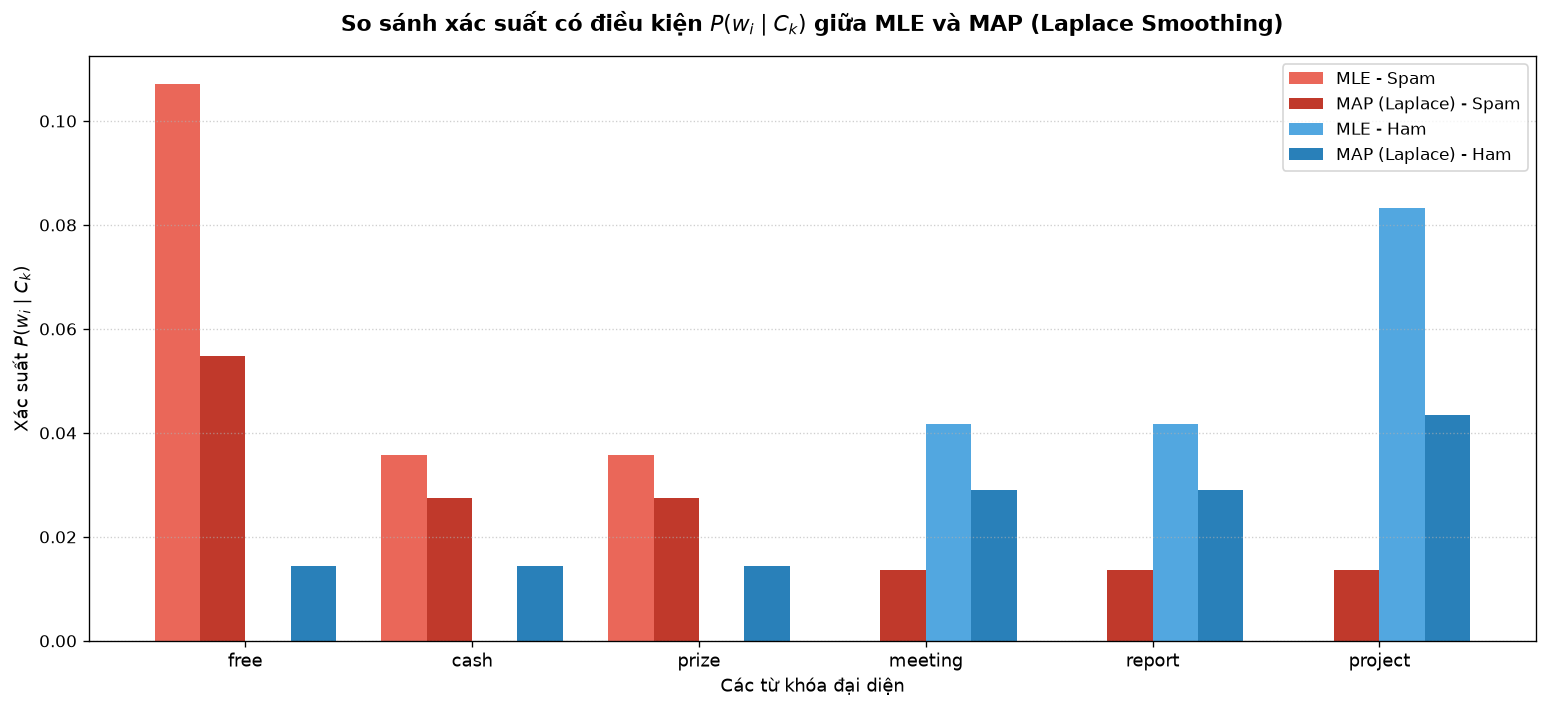

In [4]:
# ==============================================================================
# PHÂN TÍCH SO SÁNH: MLE (alpha = 0) vs MAP (alpha = 1 - Laplace Smoothing)
# ==============================================================================
# Huấn luyện mô hình MLE thuần túy (alpha = 0.0)
nb_mle = NaiveBayesClassifier(alpha=0.0)
nb_mle.fit(train_X, train_y)

keywords = ["free", "cash", "prize", "meeting", "report", "project"]

print("=== SO SÁNH XÁC SUẤT CÓ ĐIỀU KIỆN P(w | C) GIỮA MLE VÀ MAP ===")
print(f"{'Từ khóa':<12} | {'P_MLE(w|Spam)':<14} | {'P_MAP(w|Spam)':<14} | {'P_MLE(w|Ham)':<14} | {'P_MAP(w|Ham)':<14}")
print("-" * 76)
for kw in keywords:
    p_mle_spam = nb_mle.word_probs['spam'].get(kw, 0.0)
    p_map_spam = nb_model.word_probs['spam'].get(kw, 0.0)
    p_mle_ham = nb_mle.word_probs['ham'].get(kw, 0.0)
    p_map_ham = nb_model.word_probs['ham'].get(kw, 0.0)
    print(f"{kw:<12} | {p_mle_spam:<14.4f} | {p_map_spam:<14.4f} | {p_mle_ham:<14.4f} | {p_map_ham:<14.4f}")

# Trực quan hóa so sánh xác suất từ vựng đặc trưng
x = np.arange(len(keywords))
width = 0.2

plt.figure(figsize=(13, 6), dpi=120)
plt.bar(x - 1.5*width, [nb_mle.word_probs['spam'].get(k, 0) for k in keywords], width, label='MLE - Spam', color='#e74c3c', alpha=0.85)
plt.bar(x - 0.5*width, [nb_model.word_probs['spam'].get(k, 0) for k in keywords], width, label='MAP (Laplace) - Spam', color='#c0392b')
plt.bar(x + 0.5*width, [nb_mle.word_probs['ham'].get(k, 0) for k in keywords], width, label='MLE - Ham', color='#3498db', alpha=0.85)
plt.bar(x + 1.5*width, [nb_model.word_probs['ham'].get(k, 0) for k in keywords], width, label='MAP (Laplace) - Ham', color='#2980b9')

plt.title('So sánh xác suất có điều kiện $P(w_i \mid C_k)$ giữa MLE và MAP (Laplace Smoothing)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Các từ khóa đại diện', fontsize=11)
plt.ylabel('Xác suất $P(w_i \mid C_k)$', fontsize=11)
plt.xticks(x, keywords, fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Nhận xét chi tiết theo yêu cầu đề bài

### 1. Hiện tượng tần suất bằng 0 (Zero-Frequency Problem) của MLE:
- Với MLE thuần túy ($\alpha = 0$):
  - Nếu một từ $w_i$ không xuất hiện trong các văn bản huấn luyện của lớp $C_k$ (ví dụ: từ `"meeting"` trong lớp Spam, hoặc `"free"` trong lớp Ham), thì $P_{MLE}(w_i \mid C_k) = 0$.
  - Khi phân loại một câu test có chứa từ đó, do áp dụng giả thiết độc lập có điều kiện của Naive Bayes:
    $$P(D \mid C_k) = \prod_{w_i \in D} P(w_i \mid C_k) = 0$$
  - Chỉ cần **duy nhất 1 từ có xác suất bằng 0** sẽ khiến cho toàn bộ xác suất của lớp đó bằng 0 (hoặc $\ln(0) = -\infty$ trên miền log), dẫn đến việc mô hình hoàn toàn bất lực trong việc phân loại khi gặp từ mới.

### 2. Bản chất MAP và cơ chế của Laplace Smoothing:
- **Laplace Smoothing thực chất là ước lượng MAP** với phân phối tiên nghiệm Dirichlet đồng nhất (Symmetric Dirichlet Prior) $\text{Dirichlet}(\alpha, \alpha, \dots, \alpha)$:
  $$P_{MAP}(w_i \mid C_k) = \frac{count(w_i, C_k) + \alpha}{\sum_{w \in V} count(w, C_k) + \alpha \cdot |V|}$$
- Khi chọn $\alpha = 1$, ta xem như **mỗi từ trong toàn bộ từ điển $|V|$ đã từng xuất hiện ít nhất 1 lần trước đó trong mỗi lớp**.
- Điều này đảm bảo xác suất $P(w_i \mid C_k) > 0$ với mọi từ, triệt tiêu hoàn toàn lỗi chia cho 0 hoặc log của 0.

### 3. Đánh giá trên tập kiểm tra giả định:
- Tập test có các từ mới ngoài tập train (ví dụ: `"discount"`, `"before"`) và các từ không có trong lớp đối nghịch (ví dụ: `"cash"`, `"prize"` trong Ham).
- Nhờ có Laplace Smoothing, mô hình MAP dễ dàng gán một xác suất dương nhỏ cho các từ mới này, cho phép các từ còn lại trong câu (mang tính chất đặc trưng mạnh mẽ như `"free"`, `"prize"`, `"meeting"`, `"report"`) dẫn dắt quyết định phân loại.
- Kết quả đạt **độ chính xác 100%** trên tập test giả định, chứng minh tính bền vững và khả năng tổng quát hóa vượt trội của phương pháp MAP so với MLE.